In [1]:
import timeit
import matplotlib.pyplot as plt

In [2]:
def benchmark_plot(num_vals=[2,3,4], val_sizes=[3,7,10], num_trials=3, savefile=None):
    """Create a benchmark plot for evaluating performance of the grover algorithm for the subset sum problem
    """
    D = {}
    for max_val in val_sizes:
        D[max_val] = []
        for num_val in num_vals:
            D[max_val].append(timeit.timeit(f'run_grover_subset(val_set=[random.randint(-{max_val}, {max_val}) for _ in range({num_val})], target=random.randint(1,{max_val}), verbose=0, plot_probs=False)',
                                           number=num_trials,
                                           setup="from grover_main import run_grover_subset\nimport random"
                                           )
                             )
    for max_val in val_sizes:
        plt.plot(num_vals, D[max_val], label=f"{max_val}")
        plt.title("Time to compute subset sum using Grover's algorithm (only using H, x, cx, cxx gates)")
        plt.ylabel("Time (s)")
        plt.xlabel("Size of set")
        plt.legend(title="Maximum value in set")
    if savefile:
        plt.savefig(savefile)
    plt.show()

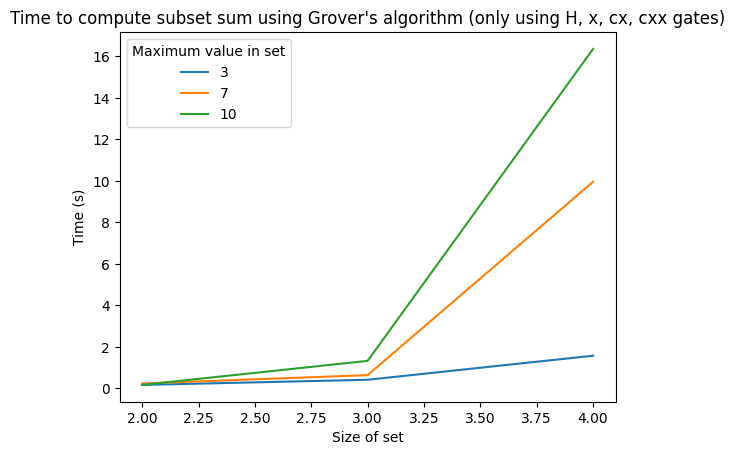

In [3]:
benchmark_plot()